<a href="https://colab.research.google.com/github/jyotiNatlekar/CSL701-CS38_Machine-Learning-Lab/blob/main/CS38exp6ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Jyoti Vijay Natlekar.
Roll No : CS38

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


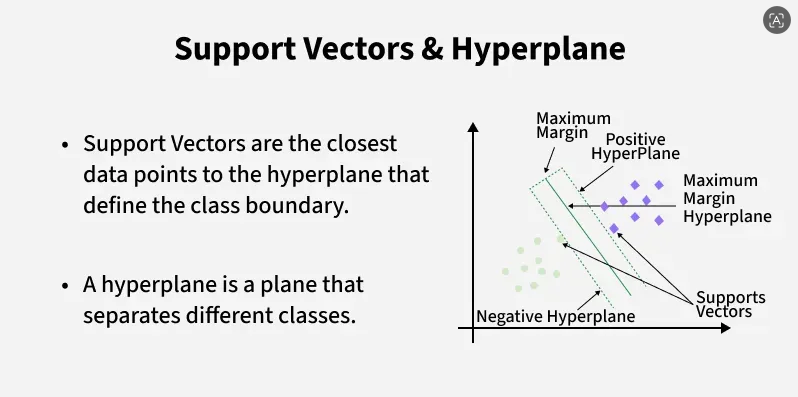
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["Species"] = iris.target

# Display first five rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


# Task 2: Explore the Dataset

In [2]:
# Display first five rows
print("First Five Rows:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display target value counts
print("\nTarget Value Counts:")
print(df["Species"].value_counts())

First Five Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape:
(150, 5)

Column Names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null  

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Select input features
X = df.drop("Species", axis=1)

# Select target variable
y = df["Species"]

# Display features
print("Features (X):")
print(X.head())

# Display target
print("\nTarget (y):")
print(y.head())

# Display shapes
print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

Features Shape: (150, 4)
Target Shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
from sklearn.svm import SVC

# Create SVM model using linear kernel
svm_model = SVC(
    kernel="linear",
    C=1.0
)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Display predictions
print("SVM Predictions:")
print(y_pred_svm)

SVM Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Accuracy: 1.0
SVM Accuracy (%): 100.0
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


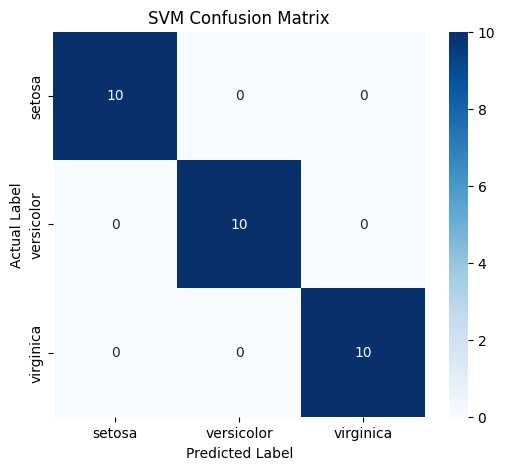

SVM Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)
print("SVM Accuracy (%):", accuracy_svm * 100)

# Confusion Matrix
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:")
print(cm_svm)

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()


# Classification Report
from sklearn.metrics import classification_report

print("SVM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=iris.target_names
    )
)

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

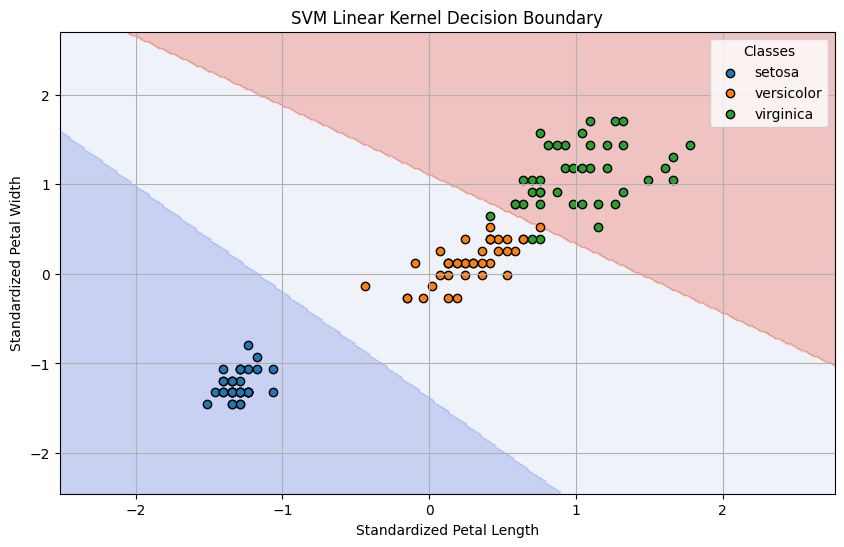

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Load Iris dataset
iris = load_iris()

# Select Petal Length and Petal Width
X = iris.data[:, [2, 3]]
y = iris.target

# 2. Split the 2-D dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train SVM using a linear kernel
svm_model = SVC(
    kernel="linear",
    C=1.0
)
svm_model.fit(X_train_scaled, y_train)

# 5. Create a mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 6. Predict values for the mesh grid
Z = svm_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z = Z.reshape(xx.shape)

# 7. Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

# 8. Plot data points for each class
for class_value in range(3):
    plt.scatter(
        X_train_scaled[y_train == class_value, 0],
        X_train_scaled[y_train == class_value, 1],
        label=iris.target_names[class_value],
        edgecolors="black"
    )

# 9. Add labels and title
plt.xlabel("Standardized Petal Length")
plt.ylabel("Standardized Petal Width")
plt.title("SVM Linear Kernel Decision Boundary")
plt.legend(title="Classes")
plt.grid(True)
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


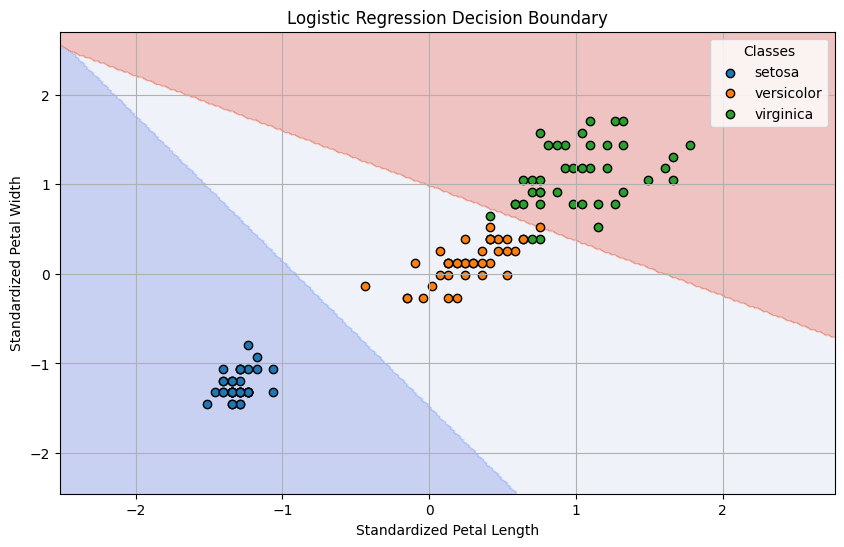

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Load Iris dataset
iris = load_iris()

# Select Petal Length and Petal Width
X = iris.data[:, [2, 3]]
y = iris.target

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=200
)

# 5. Train the model
logistic_model.fit(
    X_train_scaled,
    y_train
)

# 6. Make predictions
y_pred = logistic_model.predict(X_test_scaled)
print("Logistic Regression Predictions:")
print(y_pred)

# 7. Create mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 8. Predict mesh grid points
Z = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z = Z.reshape(xx.shape)

# 9. Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

# 10. Plot data points
for class_value in range(3):
    plt.scatter(
        X_train_scaled[y_train == class_value, 0],
        X_train_scaled[y_train == class_value, 1],
        label=iris.target_names[class_value],
        edgecolors="black"
    )

# 11. Add labels and title
plt.xlabel("Standardized Petal Length")
plt.ylabel("Standardized Petal Width")
plt.title("Logistic Regression Decision Boundary")
plt.legend(title="Classes")
plt.grid(True)
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

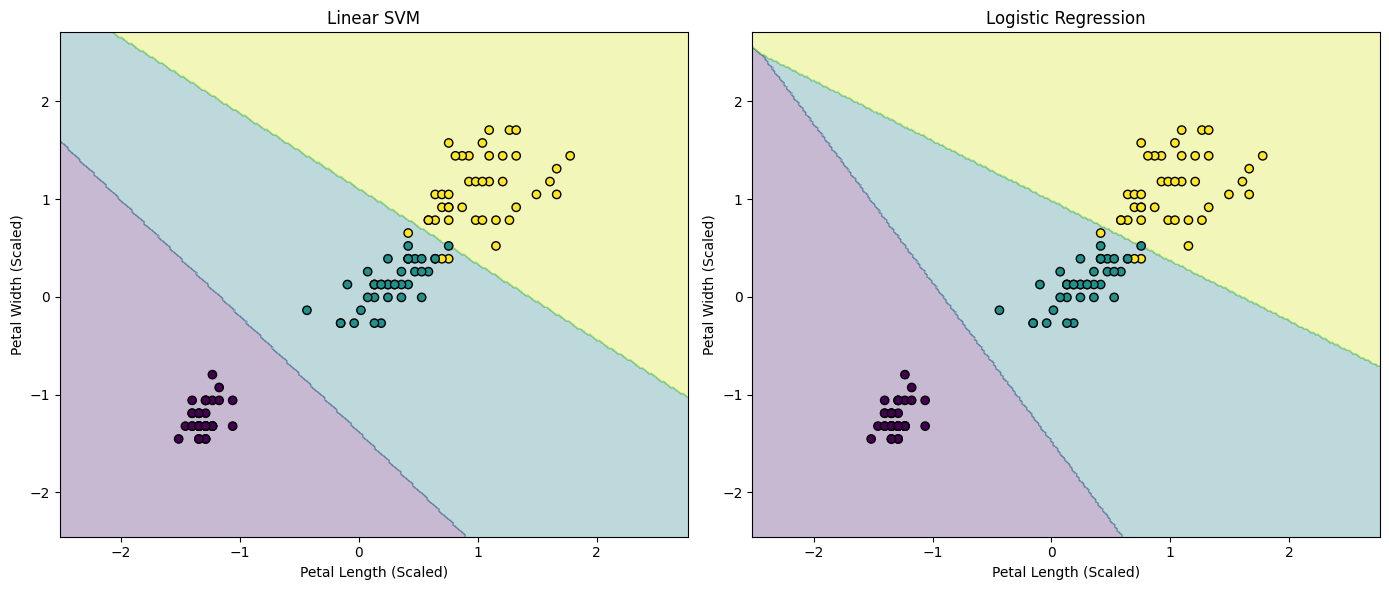

In [14]:

# Task 9: Compare SVM and Logistic Regression

# Create mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Mesh points
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# SVM predictions
Z_svm = svm_model.predict(mesh_points)
Z_svm = Z_svm.reshape(xx.shape)

# Logistic Regression predictions
Z_logistic = logistic_model.predict(mesh_points)
Z_logistic = Z_logistic.reshape(xx.shape)

# Create subplots
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# SVM plot
axes[0].contourf(
    xx,
    yy,
    Z_svm,
    alpha=0.3,
    cmap="viridis"
)

axes[0].scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    cmap="viridis",
    edgecolors="black"
)

axes[0].set_title("Linear SVM")
axes[0].set_xlabel("Petal Length (Scaled)")
axes[0].set_ylabel("Petal Width (Scaled)")

# Logistic Regression plot
axes[1].contourf(
    xx,
    yy,
    Z_logistic,
    alpha=0.3,
    cmap="viridis"
)

axes[1].scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    cmap="viridis",
    edgecolors="black"
)

axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Petal Length (Scaled)")
axes[1].set_ylabel("Petal Width (Scaled)")

plt.tight_layout()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

Linear SVM Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 0.9333333333333333


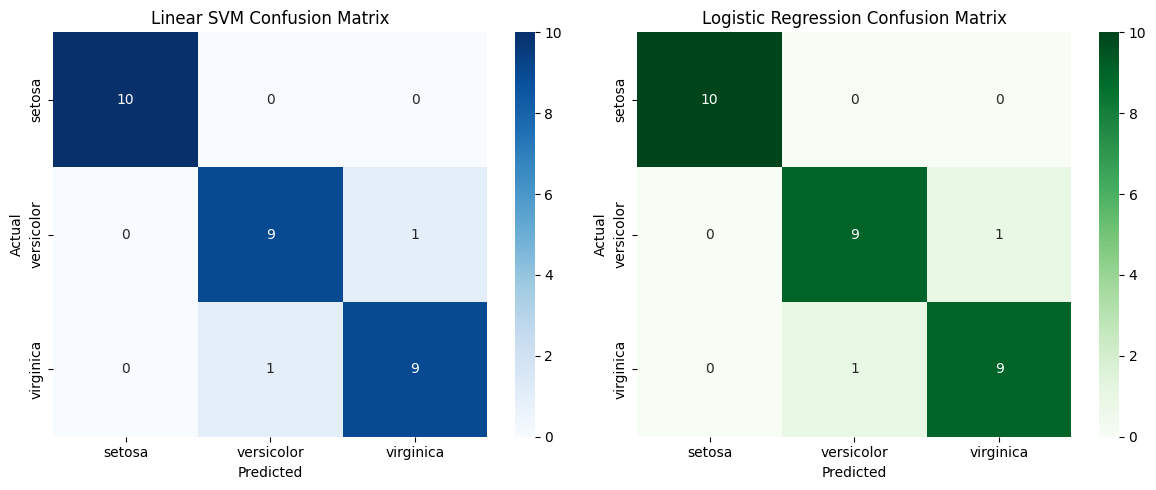

Linear SVM Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [17]:
# Generate predictions for the 2D models
y_pred_svm_2d = svm_model.predict(X_test_scaled)
y_pred_logistic_2d = logistic_model.predict(X_test_scaled)

# Calculate SVM accuracy
accuracy_svm_2D = accuracy_score(
    y_test,
    y_pred_svm_2d
)

# Calculate Logistic Regression accuracy
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic_2d
)

# Display accuracy
print("Linear SVM Accuracy:",
     accuracy_svm_2D)
print("Logistic Regression Accuracy:",
      accuracy_logistic)

# Confusion Matrices
cm_svm_2D = confusion_matrix(
    y_test,
    y_pred_svm_2d
)
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic_2d
)

# Create subplots
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# SVM confusion matrix
sns.heatmap(
    cm_svm_2D,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[0]
)
axes[0].set_title("Linear SVM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Logistic Regression confusion matrix
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[1]
)
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification Reports
print("Linear SVM Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm_2d,
        target_names=iris.target_names
    )
)
print("\nLogistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic_2d,
        target_names=iris.target_names
    )
)

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.